# Inverse Action-Angle Transformations in Spherical Potentials

`galpy.actionAngle.actionAngleSphericalInverse` computes the phase-space
coordinates $(\vec{x},\vec{v})$ corresponding to given actions and angles
$(\vec{J},\boldsymbol{\theta})$ in a spherical potential, that is, it inverts
what `actionAngleSpherical` computes. It does this by mapping the torus of the
target potential onto a torus of an isochrone potential, following the torus
mapping of [McGill & Binney (1990)](https://ui.adsabs.harvard.edu/abs/1990MNRAS.244..634M/abstract).

In [1]:
%matplotlib inline
import warnings

import numpy
from matplotlib import pyplot

from galpy.actionAngle import actionAngleSpherical, actionAngleSphericalInverse
from galpy.orbit import Orbit
from galpy.potential import LogarithmicHaloPotential

warnings.filterwarnings("ignore")
lp = LogarithmicHaloPotential(normalize=1.0, q=1.0)

## A single torus

A torus is specified by its energy and total angular momentum. Setting up the
instance performs the torus mapping, after which the transformation can be
evaluated at any set of angles. Let's take an orbit, compute its actions,
frequencies, and angles with `actionAngleSpherical`, and check that the
inverse transformation recovers the phase-space point.

In [2]:
aAS = actionAngleSpherical(pot=lp)
o = Orbit([1.0, 0.4, 1.0, 0.2, 0.3, 0.0])
E = o.E(pot=lp)
L = numpy.sqrt(numpy.sum(numpy.array(o.L()) ** 2.0))
jr, jphi, jz, Or, Op, Oz, ar, ap, az = aAS.actionsFreqsAngles(
    o.R(), o.vR(), o.vT(), o.z(), o.vz(), o.phi()
)
aASI = actionAngleSphericalInverse(pot=lp, Es=[E], Ls=[L], nta=128)
print("actions:  ", aASI._jr[0], jphi[0], jz[0])
print(
    "recovered:",
    numpy.array(aASI(aASI._jr[0], jphi[0], jz[0], ar[0], ap[0], az[0])).flatten(),
)
print("original: ", numpy.array([o.R(), o.vR(), o.vT(), o.z(), o.vz(), o.phi()]))

actions:   0.0790937383214117 1.0 0.04326410845959816
recovered: [1.         0.4        1.         0.2        0.3        6.28318531]
original:  [1.  0.4 1.  0.2 0.3 0. ]


Evaluating the transformation along the torus at the frequency rate gives the
orbit; it agrees with direct orbit integration, but is obtained without
integrating anything.

max difference: 2.0407900924723776e-09


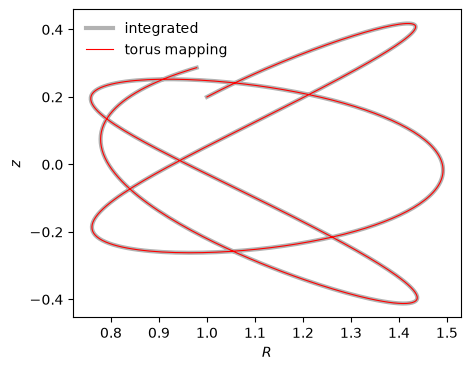

In [3]:
OmR, Omp, Omz = aASI.Freqs(aASI._jr[0], jphi[0], jz[0])
ts = numpy.linspace(0.0, 3.0 * 2.0 * numpy.pi / OmR, 501)
R, vR, vT, z, vz, phi = aASI(
    aASI._jr[0], jphi[0], jz[0], ar[0] + OmR * ts, ap[0] + Omp * ts, az[0] + Omz * ts
)
orb = Orbit([R[0], vR[0], vT[0], z[0], vz[0], phi[0]])
orb.integrate(ts, lp)
pyplot.figure(figsize=(5, 4))
pyplot.plot(orb.R(ts), orb.z(ts), "k-", lw=3.0, alpha=0.3, label="integrated")
pyplot.plot(R, z, "r-", lw=0.8, label="torus mapping")
pyplot.xlabel(r"$R$")
pyplot.ylabel(r"$z$")
pyplot.legend(frameon=False)
print("max difference:", numpy.amax(numpy.fabs(R - orb.R(ts))))

## The exact point transformation

Highly eccentric tori are difficult to map onto an isochrone torus directly.
A point transformation that first deforms the torus helps; with
`use_pointtransform="exact"`, `galpy` solves the ordinary differential
equation whose solution maps the torus *exactly* onto its auxiliary torus, so
that all mapping coefficients vanish. The transformation can then be evaluated
using the point transformation alone (`pt_only=True`), which is faster, while
the coefficients are still computed at setup as a check.

In [4]:
aASI_pt = actionAngleSphericalInverse(
    pot=lp, Es=[E], Ls=[L], nta=128, use_pointtransform="exact", pt_only=True
)
print(
    "largest mapping coefficient without a point transformation:",
    numpy.amax(numpy.fabs(aASI._nSn)),
)
print(
    "largest mapping coefficient with the exact point transformation:",
    numpy.amax(numpy.fabs(aASI_pt._nSn)),
)

largest mapping coefficient without a point transformation: 0.001544299344382953
largest mapping coefficient with the exact point transformation: 1.5170729027967546e-13


## Interpolating between tori

Setting up a torus takes of order a tenth of a second, so evaluating the
inverse transformation for many different actions is best done by setting up a
grid of tori once and interpolating between them (`setup_interp=True`). The
grid covers the angular momenta of the circular orbits between `Rmin` and
`Rmax` and, for each angular momentum, energies between that of the circular
orbit and that of an orbit reaching `Rinf`.

In [5]:
aASI_interp = actionAngleSphericalInverse(
    pot=lp,
    setup_interp=True,
    Rmin=0.3,
    Rmax=3.0,
    Rinf=20.0,
    nE=16,
    nL=16,
    nta=128,
    use_pointtransform="exact",
    pt_only=True,
)
# Any torus within the grid can now be evaluated
xv = numpy.array(aASI_interp(jr[0], jphi[0], jz[0], ar[0], ap[0], az[0])).flatten()
print("interpolated:", xv)
print(
    "difference:  ",
    numpy.amax(
        numpy.fabs(xv - numpy.array([o.R(), o.vR(), o.vT(), o.z(), o.vz(), o.phi()]))
    ),
)

interpolated: [ 9.99999849e-01  3.99999880e-01  1.00000015e+00  1.99999953e-01
  3.00000018e-01 -7.64656543e-08]
difference:   1.5145414899997434e-07


The interpolation is what makes the inverse transformation fast: once the grid
has been set up, evaluating it costs microseconds per phase-space point when a
torus is sampled at many angles at once.

In [6]:
angles = numpy.linspace(0.0, 2.0 * numpy.pi, 1001)
%timeit aASI_interp(jr[0], jphi[0], jz[0], angles, 0.0 * angles, angles)

10.8 ms ± 1.6 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Physical units

Like other `galpy` objects, the class accepts and returns
[astropy](https://www.astropy.org/) `Quantity` objects when `ro` and `vo` are
set.

In [7]:
from astropy import units

aASI_units = actionAngleSphericalInverse(
    pot=LogarithmicHaloPotential(normalize=1.0, q=1.0, ro=8.0, vo=220.0),
    Es=[E * (220.0 * units.km / units.s) ** 2.0],
    Ls=[L * 8.0 * 220.0 * units.kpc * units.km / units.s],
    nta=128,
    ro=8.0,
    vo=220.0,
)
aASI_units(
    aASI_units._jr[0] * 8.0 * 220.0 * units.kpc * units.km / units.s,
    jphi[0] * 8.0 * 220.0 * units.kpc * units.km / units.s,
    jz[0] * 8.0 * 220.0 * units.kpc * units.km / units.s,
    ar[0] * units.rad,
    ap[0] * units.rad,
    az[0] * units.rad,
)

(array([8.]),
 array([88.]),
 array([219.99999998]),
 array([1.6]),
 array([66.00000001]),
 array([6.28318531]))